In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

In [118]:
amr_matches = pd.read_csv("../data/paeruginosa/summary_matches.txt", sep="\t")

In [119]:
amr_matches

,Isolate,Beta-lactamase (not ESBL or carbapenemase),Efflux,Quinolone,Sulfonamide,Gentamicin,Chloramphenicol,Fosfomycin,ESBL (AmpC type),Kanamycin,...,Quinolone/Triclosan,Rifamycin,Chloramphenicol/Florfenicol,Lincosamides,Colistin,Beta-lactamase (narrow-spectrum),Aminoglycosides (Ribosomal methyltransferase),Other antimicrobial,Amikacin/Gentamicin/Kanamycin/Tobramycin,Penicillin resistance (Staphylococcus aureus)
0,1085_F1S1R3D1B1P5A07,blaOXA-50,"mexA,mexE,mexX*",crpP*,sul1,aac(6')-Ib4,catB7,fosA,blaPDC-8,aph(3')-IIb,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1085_F1S1R3D1B1P5A12,blaOXA-488,"mexA,mexE*,mexX*",crpP*,NaN,NaN,catB7*,fosA,blaPDC-39,aph(3')-IIb*,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1085_F1S1R3D1B1P5B07,blaOXA-50,"mexA,mexE,mexX*",crpP*,sul1,aac(6')-Ib4,catB7,fosA,blaPDC-8,aph(3')-IIb,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1085_F1S1R3D1B1P5C02,blaOXA-50,"mexA*,mexE,mexX*",crpP*,NaN,NaN,catB7*,fosA,blaPDC-14,aph(3')-IIb,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1085_F1S1R3D1B1P5C03,blaOXA-486,"mexA,mexE,mexX*",NaN,NaN,NaN,catB7*,fosA,blaPDC-24,aph(3')-IIb*,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8211,SRR8775064,blaOXA-486,"mexA,mexE,mexX*",crpP*,sul1,NaN,catB7*,fosA,blaPDC-1,aph(3')-IIb*,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8212,SRR8775066,blaOXA-486,"mexA,mexE,mexX*",crpP*,sul1,NaN,"catB7*,cmlA1",fosA,blaPDC-1,aph(3')-IIb*,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8213,SRR9902520,blaOXA-488,"mexA,mexE,mexX*",crpP*,NaN,NaN,NaN,fosA,blaPDC-34,aph(3')-IIb*,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8214,SRR9902522,blaOXA-494,"mexA,mexE,mexX*",NaN,NaN,NaN,catB7*,fosA,blaPDC-433,aph(3')-IIb*,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [122]:
def transform_amr_df(df):
    """
    Transforms an AMR category DataFrame into a binary matrix (0/1) indicating the presence of resistance genes.
    Adds an "MDR" column with 1 if three or more antibiotic classes (excluding "Efflux" and "ESBL (AmpC type)") have resistance.
    
    Parameters:
    df (pd.DataFrame): DataFrame with AMR categories as columns and resistance genes as values.
    
    Returns:
    pd.DataFrame: Transformed DataFrame with 0s and 1s, including an "MDR" column.
    """
    # Convert all values to string to handle NaN values correctly
    df_binary = df.iloc[:, 1:].notna().astype(int)
    
    # Add back the first two columns (sample identifiers)
    df_binary.insert(0, df.columns[0], df.iloc[:, 0])
    
    # Exclude "Efflux" and "ESBL (AmpC type)" from MDR calculation
    excluded_classes = ["Efflux", "ESBL (AmpC type)", "Kanamycin", "Chloramphenicol", "Fosfomycin"]
    relevant_columns = [col for col in df_binary.columns[2:] if col not in excluded_classes]
    
    # Compute MDR (1 if three or more distinct antibiotic classes have resistance)
    df_binary["MDR"] = (df_binary[relevant_columns].sum(axis=1) >= 3).astype(int)
    
    return df_binary

In [123]:
amr = transform_amr_df(amr_matches)

In [127]:
def plot_amr_category_frequency(df_binary):
    """
    Plots the frequency of resistance presence by AMR category as a bar plot with a secondary axis.
    The "MDR" bar is highlighted with alpha = 0.5.
    
    Parameters:
    df_binary (pd.DataFrame): Binary AMR DataFrame with 0s and 1s.
    """
    # Summing across rows to get frequency per category
    amr_frequencies = df_binary.iloc[:, 1:].sum().sort_values(ascending=False)
    
    # Compute MDR frequency and proportion
    mdr_frequency = df_binary["MDR"].sum()
    mdr_proportion = mdr_frequency / df_binary.shape[0]
    print(f"MDR Frequency: {mdr_frequency}")
    print(f"MDR Proportion: {mdr_proportion:.4f}")
    
    # Plot setup
    fig, ax1 = plt.subplots(figsize=(12, 8))
    
    # Primary axis - Frequency
    bars = ax1.bar(amr_frequencies.index, amr_frequencies.values, color='steelblue', label='Frequency', alpha=0.6)
    ax1.set_xlabel("AMR Category")
    ax1.set_ylabel("Frequency")
    ax1.set_xticklabels(amr_frequencies.index, rotation=45, ha="right")
    
    # Apply alpha to MDR
    for i, category in enumerate(amr_frequencies.index):
        if category == "MDR":
            bars[i].set_alpha(1)
    
    plt.title("P. aeruginosa")
    plt.tight_layout()

    plt.savefig("../out/amr_paeruginosa.svg", format="svg", dpi=150)
    plt.savefig("../out/amr_paeruginosa.png", format="png", dpi=150)
    
    plt.show()

MDR Frequency: 1219
MDR Proportion: 0.1484


/tmp/ipykernel_92441/4008662496.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(amr_frequencies.index, rotation=45, ha="right")


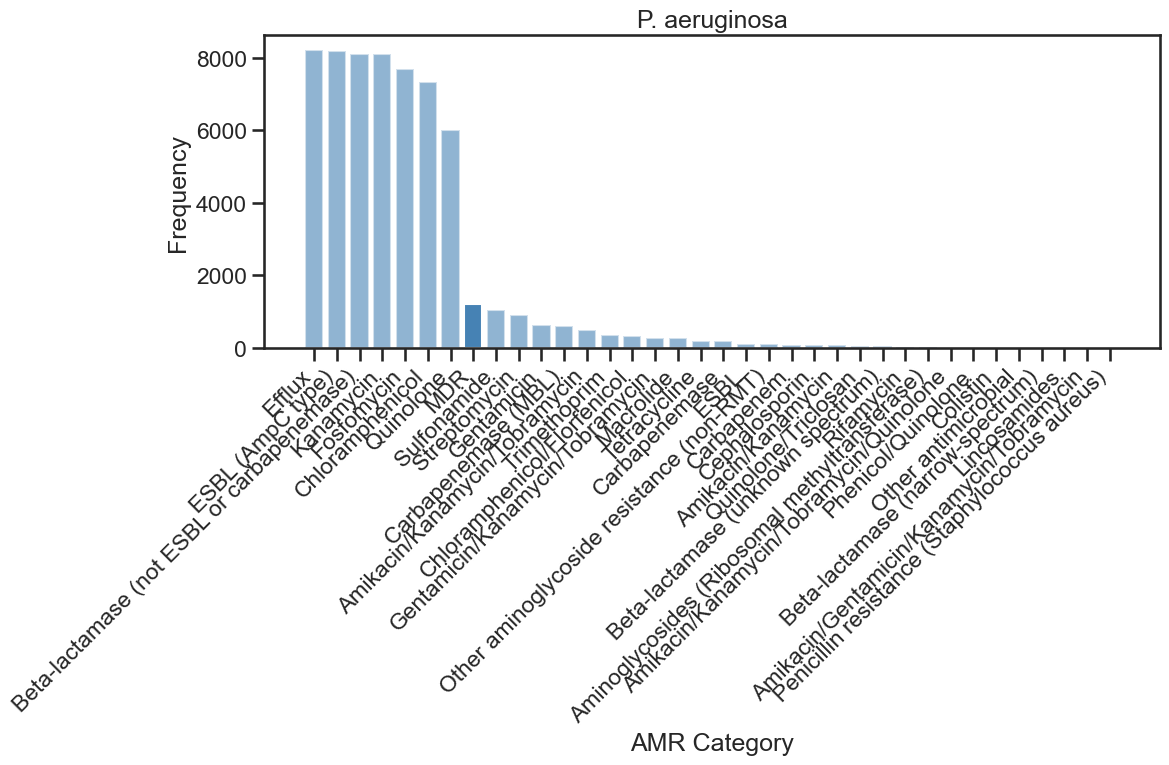

In [128]:
plot_amr_category_frequency(amr)

In [129]:
def get_mdr_combinations(df, mdr_column="MDR"):
    """
    Plots a heatmap showing the frequency of antibiotic resistance combinations leading to MDR.

    Parameters:
    df (pd.DataFrame): DataFrame containing binary resistance data for different antibiotic classes.
    mdr_column (str): The column name that indicates MDR status (default: "MDR").
    """
    if mdr_column not in df.columns:
        raise ValueError(f"Column '{mdr_column}' not found in dataframe.")

    # Identify non-antibiotic columns (assuming the first column is an identifier)
    non_antibiotic_cols = [df.columns[0], mdr_column]

    # Filter MDR-positive cases and drop non-antibiotic columns
    df_mdr = df[df[mdr_column] == 1].drop(columns=non_antibiotic_cols)

    if df_mdr.empty:
        raise ValueError("No MDR-positive cases found.")

    # Create a unique identifier for each resistance pattern
    df_mdr["Resistance Pattern"] = df_mdr.apply(lambda row: "-".join(row.astype(str)), axis=1)

    # Count the frequency of each unique resistance pattern
    pattern_counts = df_mdr["Resistance Pattern"].value_counts().reset_index()
    pattern_counts.columns = ["Resistance Pattern", "Frequency"]

    # Remove patterns that occur only once
    pattern_counts = pattern_counts[pattern_counts["Frequency"] > 1]

    # Split the resistance pattern back into individual antibiotic resistances
    pattern_expanded = pattern_counts["Resistance Pattern"].str.split("-", expand=True)
    pattern_expanded.columns = df_mdr.columns[:-1]  # Use original antibiotic column names
    pattern_expanded["Frequency"] = pattern_counts["Frequency"]

    # Convert to integer values
    for col in pattern_expanded.columns:
        pattern_expanded[col] = pd.to_numeric(pattern_expanded[col], errors="coerce").fillna(0).astype(int)

    # Convert into matrix form
    heatmap_data = pattern_expanded.set_index("Frequency").astype(int)
    
    # Transpose to have antibiotics on x-axis and patterns on y-axis
    heatmap_data = heatmap_data.T
    
    # Select only the first 50 columns
    heatmap_data = heatmap_data.iloc[:, :50]
    
    # Define the custom colormap (1 = blue, 0 = white)
    # Define the custom colormap (1 = steelblue, 0 = white)
    cmap = sns.color_palette([(1, 1, 1), (70/255, 130/255, 180/255)], as_cmap=True)

    # Plot the heatmap without annotations and without color bar
    plt.figure(figsize=(12, 8))
    sns.set_theme(style="whitegrid")
    
    ax = sns.heatmap(heatmap_data, annot=False, cmap=cmap, linewidths=0.5, cbar=False)
    
    # Add custom legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor="steelblue", edgecolor="steelblue", label="Presence"),
                       Patch(facecolor="white", edgecolor="black", label="Absence")]
    plt.legend(handles=legend_elements, loc="upper right", title="", facecolor="white", fontsize=16)
    
    plt.title("P. aeruginosa", fontsize=20)
    plt.xlabel("# Samples with the MDR Pattern", fontsize=16)
    plt.ylabel("Antibiotics", fontsize=16)
    plt.xticks(rotation=90, ha="right", fontsize=16)
    plt.yticks(rotation=0, fontsize=16)
    
    plt.savefig("../out/mdr_patterns_paeruginosa.svg", format="svg", dpi=150)
    plt.savefig("../out/mdr_patterns_paeruginosa.png", format="png", dpi=150)

    plt.show()
    
    return heatmap_data

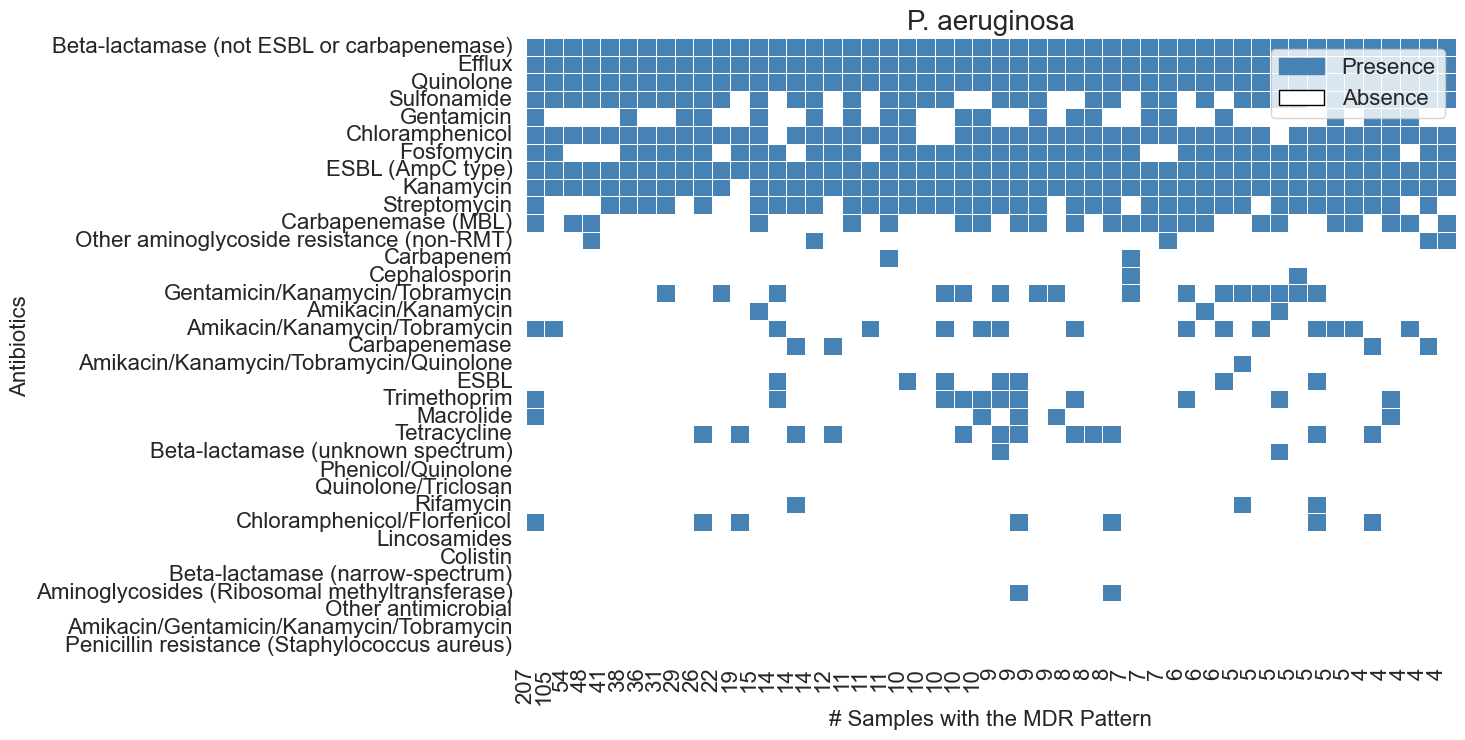

Frequency,207,105,54,48,41,38,36,31,29,26,...,5,5,5,5,5,4,4,4,4,4
Beta-lactamase (not ESBL or carbapenemase),1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
Efflux,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
Quinolone,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
Sulfonamide,1,1,1,1,1,1,1,1,1,1,...,1,1,0,1,1,1,1,1,1,1
Gentamicin,1,0,0,0,0,1,0,0,1,1,...,0,0,0,1,0,1,1,1,0,0
Chloramphenicol,1,1,1,1,1,1,1,1,1,1,...,0,1,1,1,1,1,1,1,1,1
Fosfomycin,1,1,0,0,0,1,1,1,1,1,...,1,1,1,1,1,1,1,0,1,1
ESBL (AmpC type),1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
Kanamycin,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
Streptomycin,1,0,0,0,1,1,1,1,0,1,...,1,1,1,1,1,1,1,0,1,0


In [130]:
get_mdr_combinations(amr)